# Second Serve — KNN Receiver Matching

Builds a BallTree KNN model on receiver locations.
Run this AFTER food_decay_model.ipynb.

In production the tree is rebuilt whenever new receivers register.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
import joblib
import os

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)

print('Libraries loaded')

Libraries loaded


## 1. Simulate Receiver Locations

In production this pulls directly from the live database.
For training we simulate Mumbai + Pune area receivers.

In [2]:
np.random.seed(42)

receivers_df = pd.DataFrame({
    'receiver_id': range(1, 101),
    'name': [f'NGO_{i}' for i in range(1, 101)],
    'latitude': np.concatenate([
        np.random.uniform(18.85, 19.30, 60),   # Mumbai
        np.random.uniform(18.40, 18.65, 40)    # Pune
    ]),
    'longitude': np.concatenate([
        np.random.uniform(72.75, 73.00, 60),   # Mumbai
        np.random.uniform(73.75, 74.00, 40)    # Pune
    ]),
    'veg_only': np.random.choice(['yes', 'no'], 100, p=[0.4, 0.6])
})

print('Receivers shape:', receivers_df.shape)
print('Veg only count:', receivers_df['veg_only'].value_counts().to_dict())
receivers_df.head()

Receivers shape: (100, 5)
Veg only count: {'no': 61, 'yes': 39}


,receiver_id,name,latitude,longitude,veg_only
0,1,NGO_1,19.018543,72.757857,no
1,2,NGO_2,19.277821,72.909103,yes
2,3,NGO_3,19.179397,72.828589,yes
3,4,NGO_4,19.119396,72.877143,no
4,5,NGO_5,18.920208,72.976892,no


## 2. Visualize Receiver Locations

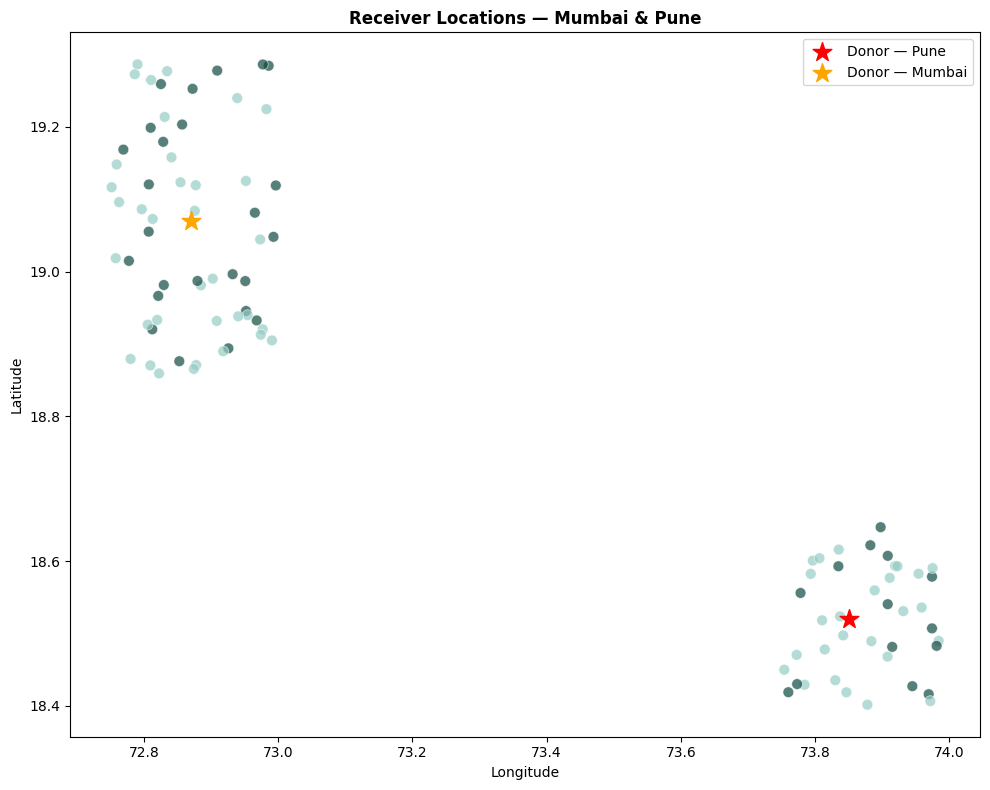

In [3]:
plt.figure(figsize=(10, 8))

colors = receivers_df['veg_only'].map({'yes': '#114a42', 'no': '#95ccc5'})
plt.scatter(
    receivers_df['longitude'], receivers_df['latitude'],
    c=colors, alpha=0.7, s=60, edgecolors='white', linewidth=0.5
)

# Test donor points
plt.scatter(73.85, 18.52, c='red', s=200, marker='*', zorder=5, label='Donor — Pune')
plt.scatter(72.87, 19.07, c='orange', s=200, marker='*', zorder=5, label='Donor — Mumbai')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Receiver Locations — Mumbai & Pune', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/receiver_locations.png', dpi=150)
plt.show()

## 3. Build BallTree KNN

BallTree with haversine metric is correct for geographic lat/lon data.
Haversine measures great-circle distance on the Earth's surface.

In [4]:
# Convert to radians — required for haversine metric
coords_rad = np.radians(receivers_df[['latitude', 'longitude']].values)

# Build BallTree
tree = BallTree(coords_rad, metric='haversine')

print('BallTree built on', len(receivers_df), 'receivers')

BallTree built on 100 receivers


## 4. Test — Find Nearest Receivers

In [5]:
def find_nearest(lat, lon, k=5):
    donor_rad = np.radians([[lat, lon]])
    distances, indices = tree.query(donor_rad, k=k)
    distances_km = distances[0] * 6371  # radians to km

    result = receivers_df.iloc[indices[0]].copy()
    result['distance_km'] = distances_km.round(2)

    return result[['receiver_id','name','latitude','longitude','veg_only','distance_km']]


print('Nearest to Pune donor (18.52, 73.85):')
print(find_nearest(18.52, 73.85, k=5).to_string(index=False))

print('\nNearest to Mumbai donor (19.07, 72.87):')
print(find_nearest(19.07, 72.87, k=5).to_string(index=False))

Nearest to Pune donor (18.52, 73.85):
 receiver_id   name  latitude  longitude veg_only  distance_km
          96 NGO_96 18.523449  73.837302       no         1.39
          61 NGO_61 18.497169  73.841946       no         2.68
          90 NGO_90 18.518054  73.810463       no         4.17
          64 NGO_64 18.489188  73.883944       no         4.95
          88 NGO_88 18.559389  73.888800       no         5.99

Nearest to Mumbai donor (19.07, 72.87):
 receiver_id   name  latitude  longitude veg_only  distance_km
          48 NGO_48 19.084031  72.875670       no         1.67
           4  NGO_4 19.119396  72.877143       no         5.54
          42 NGO_42 19.072830  72.812946       no         6.00
          31 NGO_31 19.123395  72.854353       no         6.16
          25 NGO_25 19.055231  72.806984      yes         6.82


## 5. Visualize Nearest Receivers

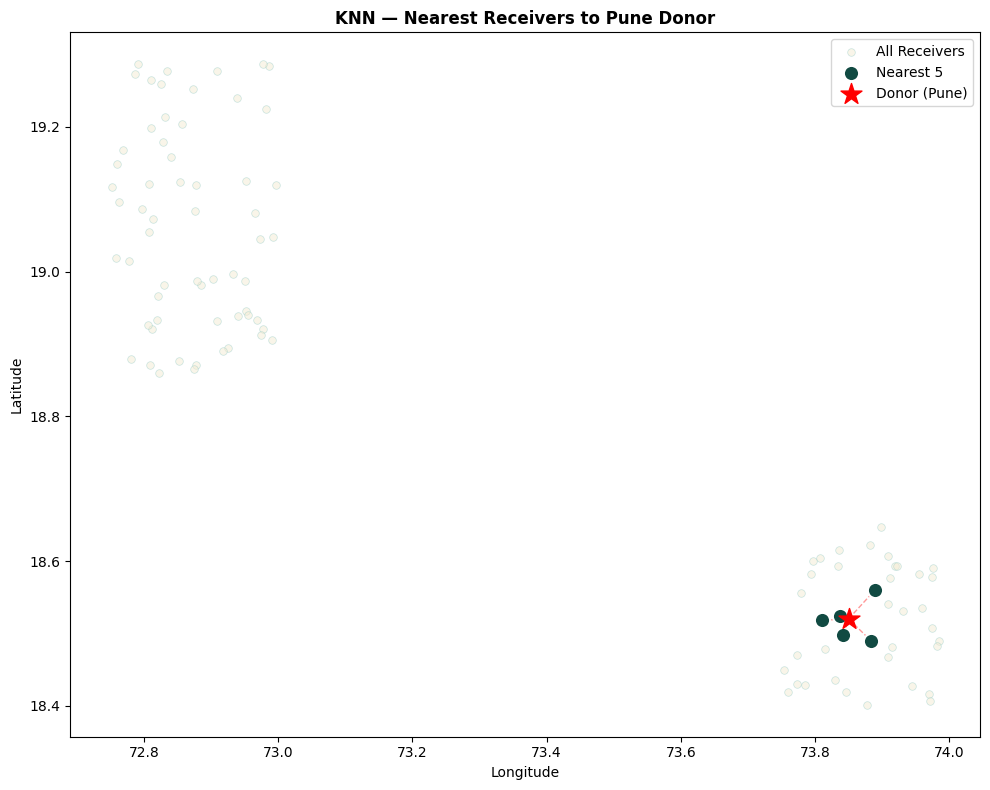

In [6]:
nearest = find_nearest(18.52, 73.85, k=5)

plt.figure(figsize=(10, 8))
plt.scatter(receivers_df['longitude'], receivers_df['latitude'],
            c='#f5ecd5', alpha=0.5, s=30, edgecolors='#95ccc5', linewidth=0.5,
            label='All Receivers')

plt.scatter(nearest['longitude'], nearest['latitude'],
            c='#114a42', s=120, zorder=3, edgecolors='white', linewidth=1.5,
            label='Nearest 5')

plt.scatter(73.85, 18.52, c='red', s=250, marker='*', zorder=4, label='Donor (Pune)')

# Draw lines from donor to nearest
for _, row in nearest.iterrows():
    plt.plot([73.85, row['longitude']], [18.52, row['latitude']],
             'r--', alpha=0.4, linewidth=1)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('KNN — Nearest Receivers to Pune Donor', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/knn_nearest_pune.png', dpi=150)
plt.show()

## 6. Save KNN Model and Reference

In [7]:
joblib.dump(tree, 'models/knn_receiver_tree.pkl')
receivers_df.to_csv('models/receivers_reference.csv', index=False)

print('KNN model saved: models/knn_receiver_tree.pkl')
print('Receivers ref saved: models/receivers_reference.csv')

KNN model saved: models/knn_receiver_tree.pkl
Receivers ref saved: models/receivers_reference.csv
